In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/tr_server_data.csv", header=None, names=["feature_1","feature_2"])

In [5]:
df.head()

,feature_1,feature_2
0,13.047,14.741
1,13.409,13.763
2,14.196,15.853
3,14.915,16.174
4,13.577,14.043


In [6]:
df.shape

(307, 2)

In [7]:
df.describe()

,feature_1,feature_2
count,307.000000,307.000000
mean,14.112253,14.997675
std,1.355974,1.309696
min,4.752600,4.126200
25%,13.403500,14.362000
50%,14.060000,15.023000
75%,14.675500,15.654500
max,23.340000,24.350000


In [8]:
df.isnull().sum()

,0
feature_1,0
feature_2,0


### Preprocessing

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

In [11]:
X_scaled= scaler.fit_transform(df)

In [16]:
X_scaled

array([[-7.86882024e-01, -1.96300307e-01],
       [-5.19479487e-01, -9.44257857e-01],
       [ 6.18624919e-02,  6.54138136e-01],
       [ 5.92974160e-01,  8.99633406e-01],
       [-3.95381072e-01, -7.30118681e-01],
       [-1.40536113e-01, -1.21728531e+00],
       [-9.53085258e-01, -5.92457782e-01],
       [ 1.15511043e+00,  6.83964664e-01],
       [ 1.51484810e+00,  9.21812106e-01],
       [-1.06831950e+00, -7.54646286e-02],
       [-9.39992076e-02, -1.55990799e+00],
       [-3.78594485e-02, -3.43138599e-01],
       [-5.33514427e-01,  4.31586349e-01],
       [-5.30559703e-01,  4.81297229e-01],
       [-9.84312939e-02, -1.31288315e+00],
       [ 4.11794228e-02, -4.06615569e-01],
       [-1.10988872e-01, -1.87887696e-01],
       [ 2.56135606e-01,  5.53132254e-02],
       [ 3.49209417e-01,  6.34253784e-01],
       [-1.50561868e+00, -1.47654667e+00],
       [-4.16064141e-01,  4.13231563e-01],
       [-9.32605266e-02, -1.60355516e-01],
       [ 6.33601617e-01,  1.16271868e+00],
       [ 1.

## Train model using Isolation Forest

In [13]:
from sklearn.ensemble import IsolationForest

In [30]:
model = IsolationForest(
    n_estimators=300,
    contamination = 0.05, # 5 %
    random_state= 42
)

In [31]:
model.fit(X_scaled)

IsolationForest(contamination=0.05, n_estimators=300, random_state=42)

## Detect Anomalies

In [32]:
#prediction
# -1 = anomaly, 1 = normal

In [33]:
model.predict(X_scaled)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1

In [34]:
df.head(20)

,feature_1,feature_2,anomaly
0,13.047,14.741,1
1,13.409,13.763,1
2,14.196,15.853,1
3,14.915,16.174,1
4,13.577,14.043,1
5,13.922,13.406,1
6,12.822,14.223,1
7,15.676,15.892,1
8,16.163,16.203,1
9,12.666,14.899,1


In [35]:
df["anomaly"] = model.predict(X_scaled)

In [36]:
df.head()

,feature_1,feature_2,anomaly
0,13.047,14.741,1
1,13.409,13.763,1
2,14.196,15.853,1
3,14.915,16.174,1
4,13.577,14.043,1


In [37]:
df.tail()

,feature_1,feature_2,anomaly
302,12.4770,14.459,1
303,19.5830,10.412,-1
304,23.3400,16.299,-1
305,18.2610,17.978,-1
306,4.7526,24.350,-1


# Task
Count the number of normal and anomalous data points in the `df` DataFrame, and then create a scatter plot of 'feature_1' versus 'feature_2' from the `df` DataFrame, where points are color-coded based on their 'anomaly' status, including a legend.

## Count Anomalies

### Subtask:
Count the number of data points classified as normal (1) and anomalous (-1) by the Isolation Forest model.


**Reasoning**:
To count the number of data points classified as normal (1) and anomalous (-1), I will use the `value_counts()` method on the 'anomaly' column of the `df` DataFrame.



In [38]:
anomaly_counts = df['anomaly'].value_counts()
print(anomaly_counts)

anomaly
 1    291
-1     16
Name: count, dtype: int64


## Visualize Anomalies

### Subtask:
Create a scatter plot of 'feature_1' versus 'feature_2' from the `df` DataFrame, where points are color-coded based on their 'anomaly' status, including a legend.

#### Instructions
1. Plot 'feature_1' on the x-axis and 'feature_2' on the y-axis.
2. Color the data points based on the 'anomaly' column (1 for normal, -1 for anomaly).
3. Add a legend to distinguish between normal and anomalous points.
4. Label the x and y axes appropriately.
5. Give the plot a title.

**Reasoning**:
To visualize the anomalies, I will create a scatter plot of 'feature_1' versus 'feature_2', color-coding the points based on their 'anomaly' status, and include appropriate labels, title, and a legend.



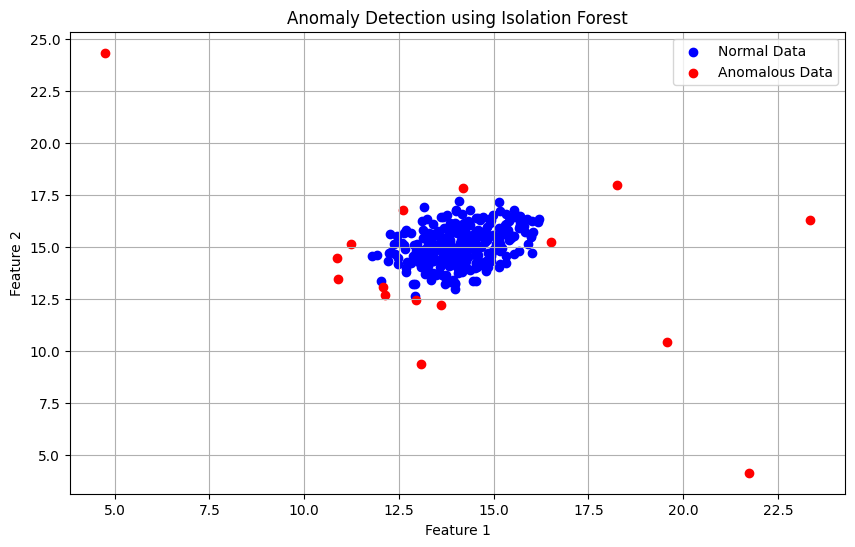

In [39]:
plt.figure(figsize=(10, 6))
normal = df[df['anomaly'] == 1]
anomaly = df[df['anomaly'] == -1]
plt.scatter(normal['feature_1'], normal['feature_2'], color='blue', label='Normal Data')
plt.scatter(anomaly['feature_1'], anomaly['feature_2'], color='red', label='Anomalous Data')
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


## Final Task

### Subtask:
Summarize the count of detected anomalies and interpret the visualization to evaluate the model's performance.


## Summary:

### Q&A
*   **What is the count of detected anomalies?**
    There are 291 normal data points and 16 anomalous data points.
*   **How can the visualization be interpreted to evaluate the model's performance?**
    The scatter plot visually separates the anomalous data points (red) from the normal data points (blue). The red points appear to be outliers relative to the main cluster of blue points, which indicates that the Isolation Forest model has successfully identified distinct anomalous instances that deviate from the normal data distribution.

### Data Analysis Key Findings
*   The dataset contains 291 normal data points (labeled as 1) and 16 anomalous data points (labeled as -1).
*   A scatter plot of 'feature_1' versus 'feature_2' was successfully generated, visualizing the data points.
*   Normal data points are represented in blue, while anomalous data points are distinctively shown in red, allowing for clear visual differentiation.
*   The plot includes a title, labeled axes ('Feature 1' and 'Feature 2'), and a legend, fulfilling all visualization requirements.

### Insights or Next Steps
*   The Isolation Forest model effectively identified a small proportion of anomalies (approximately 5.2% of the total data points, 16 out of 307), which are visually distinct as outliers in the 2D feature space.
*   Further investigation could involve examining the characteristics of the anomalous points to understand the underlying causes of their anomalous behavior or assessing other features if available to gain a more comprehensive view of the anomalies.


In [28]:
df.head(50)

,feature_1,feature_2,anomaly
0,13.047,14.741,1
1,13.409,13.763,1
2,14.196,15.853,1
3,14.915,16.174,1
4,13.577,14.043,1
5,13.922,13.406,1
6,12.822,14.223,1
7,15.676,15.892,1
8,16.163,16.203,1
9,12.666,14.899,1


In [29]:
df.tail(10)

,feature_1,feature_2,anomaly
297,14.5580,15.4870,1
298,14.2250,15.8610,1
299,12.0400,13.3450,1
300,13.0790,9.3479,-1
301,21.7270,4.1262,-1
302,12.4770,14.4590,1
303,19.5830,10.4120,-1
304,23.3400,16.2990,-1
305,18.2610,17.9780,-1
306,4.7526,24.3500,-1
